In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# 20 - CUPED variance reduction
CUPED subtracts the part of each user's metric that was predictable from before the test, so the remaining noise is smaller. The gain is **rho squared**, where rho is the correlation between the pre-period covariate and the metric.

 rho  measured_reduction  theory_rho2
 0.0               0.000         0.00
 0.2               0.040         0.04
 0.4               0.161         0.16
 0.6               0.359         0.36
 0.8               0.640         0.64
 0.9               0.811         0.81


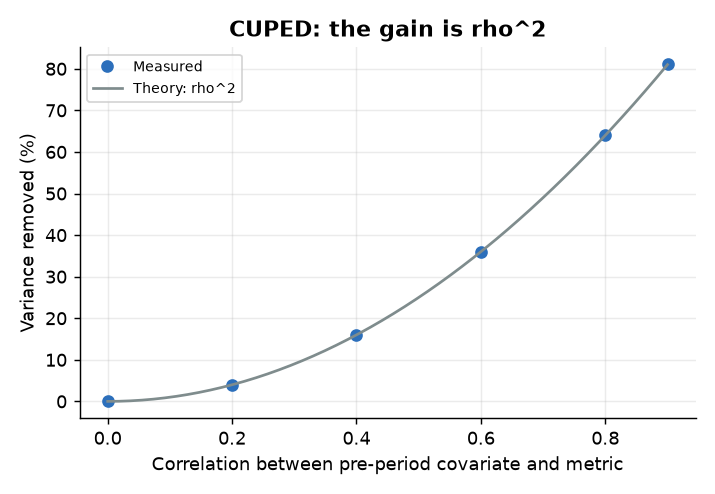

In [2]:
v = json.load(open(RES + "validation.json"))
print(pd.DataFrame(v["cuped_rho"]).round(3).to_string(index=False))
from IPython.display import Image
Image("../reports/figures/cuped_rho2.png")

In [3]:
print("Simulated sparse revenue metric:", v["cuped_sim"])

Simulated sparse revenue metric: {'aa_fpr_raw': 0.04666666666666667, 'aa_fpr_cuped': 0.043333333333333335, 'power_raw': 0.18833333333333332, 'power_cuped': 0.18333333333333332, 'note': 'revenue is sparse (5% convert), so the pre-period covariate helps only modestly'}


Revenue is sparse (only 5% of users convert), so a pre-period spend covariate helps only modestly there. Real data shows the range:

In [4]:
r = json.load(open(RES + "real_data.json"))
a = r["criteo"]["ancova"]
for m in a: print(f'Criteo {m}: SE reduced {a[m]["se_reduction"]:.1%}, same precision with {a[m]["sample_needed_ratio"]:.0%} of the users')
h = r["hillstrom"]; print(f'Hillstrom spend: corr with past spend {h["corr_history_spend"]:.3f}, variance removed {h["variance_reduction_python"]:.3%}')

Criteo visit: SE reduced 13.7%, same precision with 74% of the users
Criteo conversion: SE reduced 6.1%, same precision with 88% of the users
Hillstrom spend: corr with past spend 0.020, variance removed 0.038%


**So what:** CUPED turns a good covariate into shorter tests (Criteo visits: about a quarter fewer users for the same precision) and does nothing with a weak one (Hillstrom). Always check the covariate's correlation before promising a speed-up, and verify the method keeps the A/A false positive rate at 5%.